In [18]:
import pandas as pd
import sklearn as sk
import matplotlib.pyplot as plt
import os

In [27]:
file = '/home/ace/Desktop/DontKnow/Customer-Segmentation/dataset/Mall_Customers2.csv'
df=pd.read_csv(file)

In [28]:
display(df.head())
display(df.tail())

,CustomerID,Gender,Age,AnnualIncome,SpendingScore
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


,CustomerID,Gender,Age,AnnualIncome,SpendingScore
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [29]:
df.drop_duplicates()
df.dropna()

,CustomerID,Gender,Age,AnnualIncome,SpendingScore
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [31]:
data = df.loc[:, ['AnnualIncome', 'SpendingScore']]
data.head()

,AnnualIncome,SpendingScore
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [33]:
scaler=sk.preprocessing.StandardScaler()
df=scaler.fit_transform(data)

In [80]:
r1=int(input('Enter lower range limit for number of segments:'))
r2=int(input('Enter lower range limit for number of segments:'))

Enter lower range limit for number of segments: 2
Enter lower range limit for number of segments: 9


In [81]:
elbow=[]

for k in range(r1,r2+1):
    kmeans=sk.cluster.KMeans(n_clusters=k, random_state=77, n_init=10)
    kmeans.fit(df)
    elbow.append(kmeans.inertia_)

In [82]:
temp=[]
for i in range(len(elbow)-1):
    temp.append(abs(elbow[i]-elbow[i+1]))

temp2=[]
for i in range(len(temp)-1):
    temp2.append(abs(temp[i]-temp[i+1]))

In [83]:
temp

[111.31278559870717,
 48.7826915367158,
 43.35290845792677,
 10.464630034566255,
 8.191457962689583,
 9.272397259504963,
 5.1448416998550925]

In [84]:
temp2

[62.53009406199136,
 5.429783078789029,
 32.88827842336052,
 2.2731720718766724,
 1.0809392968153801,
 4.1275555596498705]

In [85]:
ind=temp2.index(max(temp2))
elbow_point = ind+1+r1

In [86]:
silhouette=[]
for k in range(r1,r2+1):
    kmeans=sk.cluster.KMeans(n_clusters=k, random_state=77, n_init=10)
    pred=kmeans.fit_predict(df)
    score=sk.metrics.silhouette_score(df,pred)
    silhouette.append(score)

In [87]:
recmd_ind=silhouette.index(max(silhouette[elbow_point-1:elbow_point+1]))

In [94]:
kmeans=sk.cluster.KMeans(n_clusters=recmd_ind, random_state=77, n_init=10)
labels=kmeans.fit_predict(df)

In [95]:
centers=kmeans.cluster_centers_
X=df

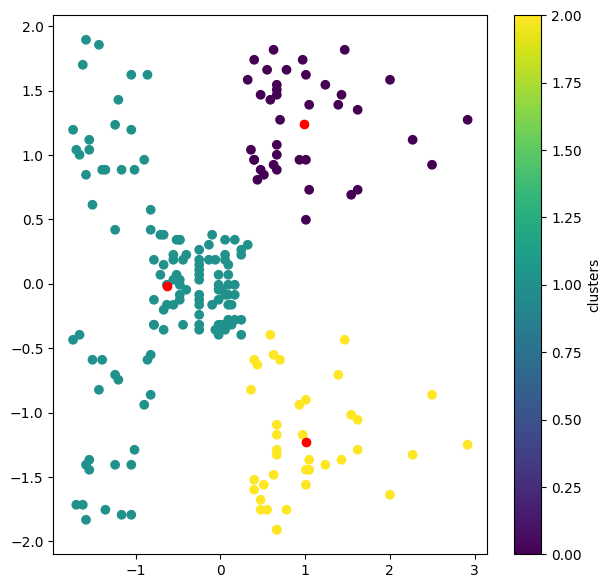

In [96]:
plt.figure(figsize=(7,7))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis')
plt.colorbar(label='clusters')
plt.scatter(centers[:,0], centers[:,1], c='red', label='Centroids')

In [97]:
data['cluster']=kmeans.labels_

In [99]:
data

,AnnualIncome,SpendingScore,cluster
0,15,39,1
1,15,81,1
2,16,6,1
3,16,77,1
4,17,40,1
...,...,...,...
195,120,79,0
196,126,28,2
197,126,74,0
198,137,18,2


In [100]:
data.to_csv('/home/ace/Desktop/DontKnow/Customer-Segmentation/dataset/Mall_Customers_processed2.csv')